## Extend the evaluation of calibration to the hard datasets

I extended the analysis of probability calibration to the hard datasets which are a bit bigger than those from reel and imblearn. The conclusion stands: with imbalanced classes and small held out samples is hard to assess calibration. 

**caveat**: we are not using the entire credit risk dataset. We should re-do this notebook if we change the models to be trained on the entire dataset instead.

In [1]:
import sys
sys.path.insert(1, '../')

In [2]:
import joblib

import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

from functions.hard_data import DATASETS_HARD, load_hard_dataset

datasets = DATASETS_HARD
datasets

['diabetes130', 'default_credit', 'secom']

In [3]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", message="The total space of parameters")
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

## Load results

In [4]:
models = [
  'rf', 'ada', 'gbm', 'cat', 'lgbm', 'xgb'
  ]

In [5]:
# the number of datasets to analyse
len(datasets)

3

## Raw models

In [6]:
def plot_models(results, y_test, dataset, bins=6):
    
    N = len(models)
    fig, axes = plt.subplots(2, N, figsize=(4 * N, 8))
    
    title = f"{dataset}: Score Distributions & Calibration\n{len(y_test)} samples"
    fig.suptitle(title, fontsize=20, y=1.02)
    
    for col, name in enumerate(models):
        probs = results[name]["probs"]
        
        # ── Top: score distribution ───────────────────────────────────────
        ax = axes[0, col]
        ax.hist(probs, bins=20, density=True, color="#4C72B0", alpha=0.8)
        ax.set_title(name, fontsize=14, pad=8)
        ax.set_xlim(0, 1)
        ax.set_xlabel("Predicted probability", fontsize=12)
        ax.set_ylabel("Density" if col == 0 else "", fontsize=12)
        ax.tick_params(axis="both", labelsize=11)
        
        # ── Bottom: calibration curve + bin count bars ────────────────────
        ax  = axes[1, col]
        ax2 = ax.twinx()
        
        # equal-width bin bars
        edges = np.linspace(0, 1, bins+1)  # equal-width bins
        bin_widths  = np.diff(edges)
        bin_centers = (edges[:-1] + edges[1:]) / 2
        counts = [
            np.sum((probs >= edges[i]) & (probs < edges[i + 1]))
            for i in range(len(edges) - 1)
        ]
        ax2.bar(bin_centers, counts, width=bin_widths,
                color="bisque", alpha=0.6, edgecolor="sandybrown",
                linewidth=0.8, align="center")
        ax2.set_ylabel("Count per bin" if col == N - 1 else "", fontsize=12)
        ax2.tick_params(axis="y", labelsize=11)
        ax2.set_ylim(0, max(counts) * 2)
        
        # calibration curve + std shade
        fraction_pos, mean_pred = calibration_curve(
            y_test, probs, n_bins=bins, strategy="uniform"
        )
        
        # compute per-bin std of the raw probabilities
        stds = [
            probs[(probs >= edges[i]) & (probs < edges[i + 1])].std() if np.sum((probs >= edges[i]) & (probs < edges[i + 1])) > 1 else 0.0
            for i in range(len(edges) - 1)
        ]
        stds = np.array(stds[:len(mean_pred)])
        ax.fill_between(mean_pred,
                        np.clip(fraction_pos - 3 * stds, 0, 1),
                        np.clip(fraction_pos + 3 * stds, 0, 1),
                        color="lightblue", alpha=0.4, zorder=3,
                       )
        ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, zorder=3)
        ax.plot(mean_pred, fraction_pos, "o-", color="#4C72B0",
                linewidth=2, markersize=6, zorder=4)
        
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("Mean predicted probability", fontsize=12)
        ax.set_ylabel("Fraction positives" if col == 0 else "", fontsize=12)
        ax.tick_params(axis="both", labelsize=11)
        ax.set_zorder(ax2.get_zorder() + 1)
        ax.patch.set_visible(False)
    plt.tight_layout()
    plt.show()

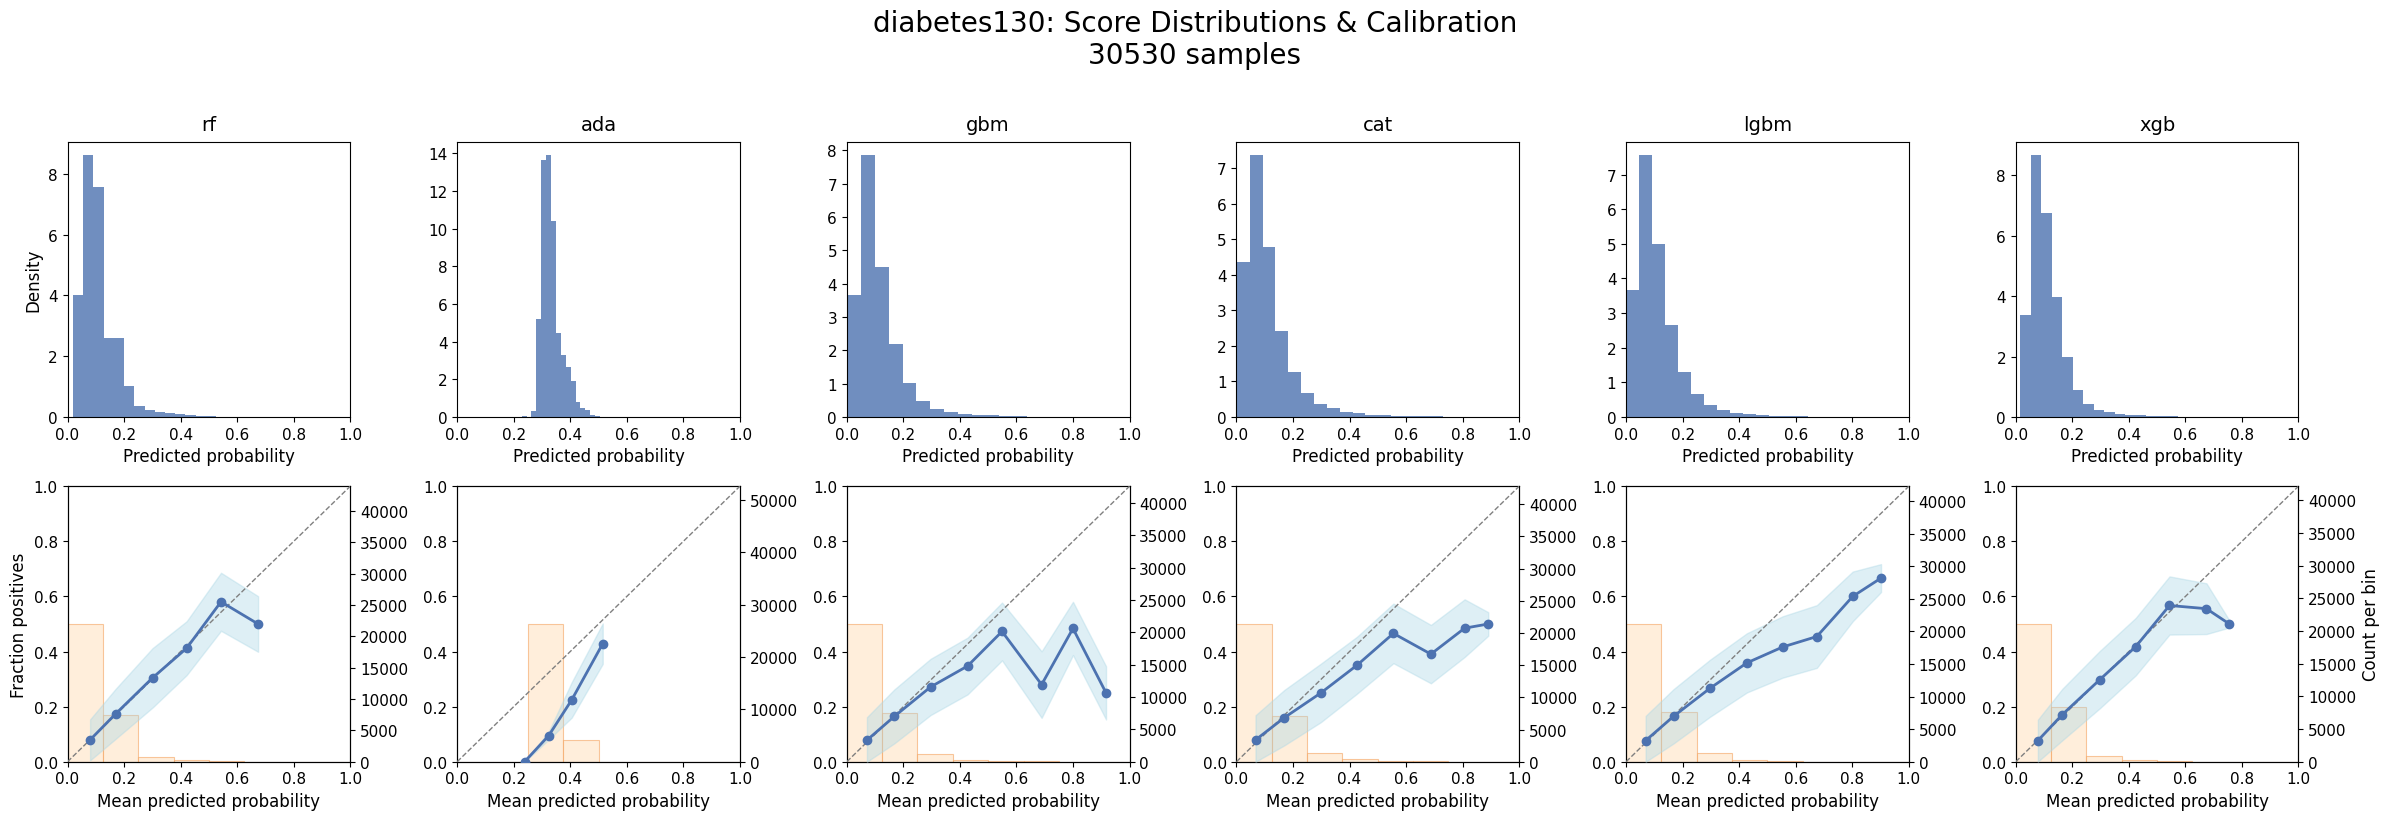

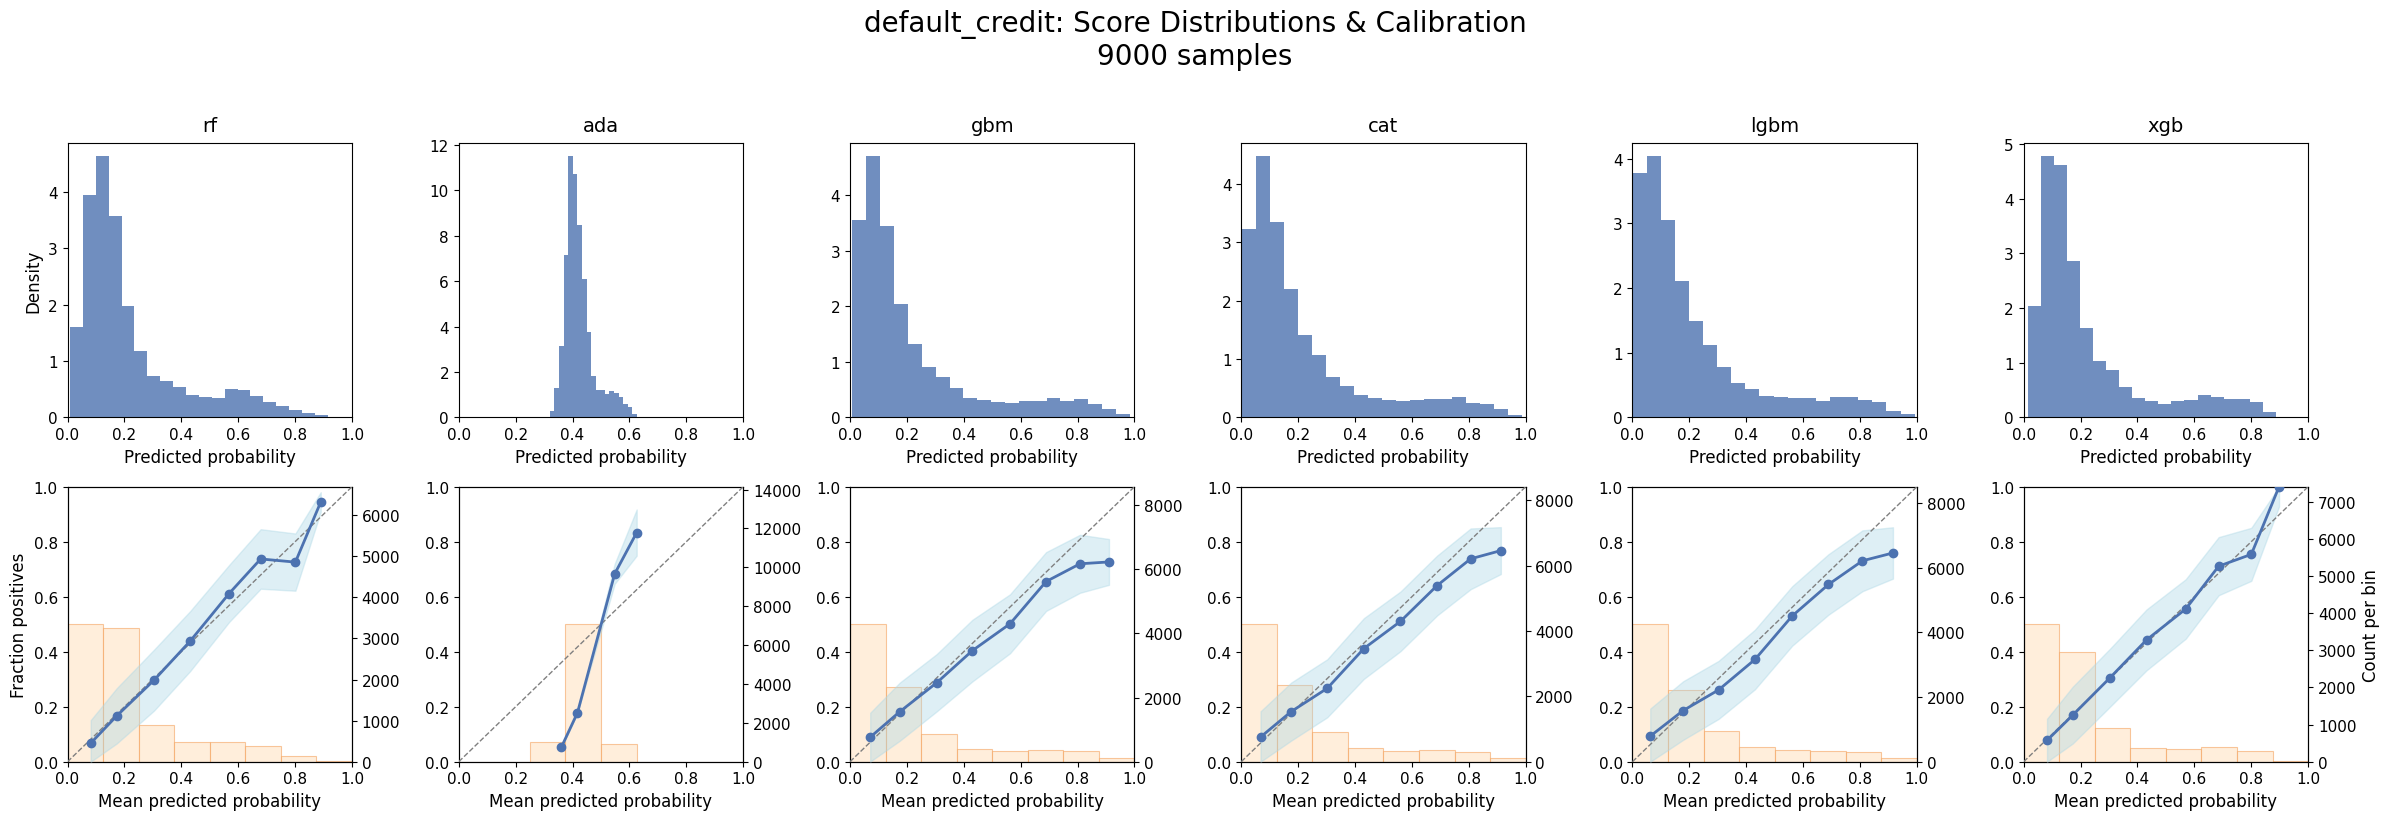

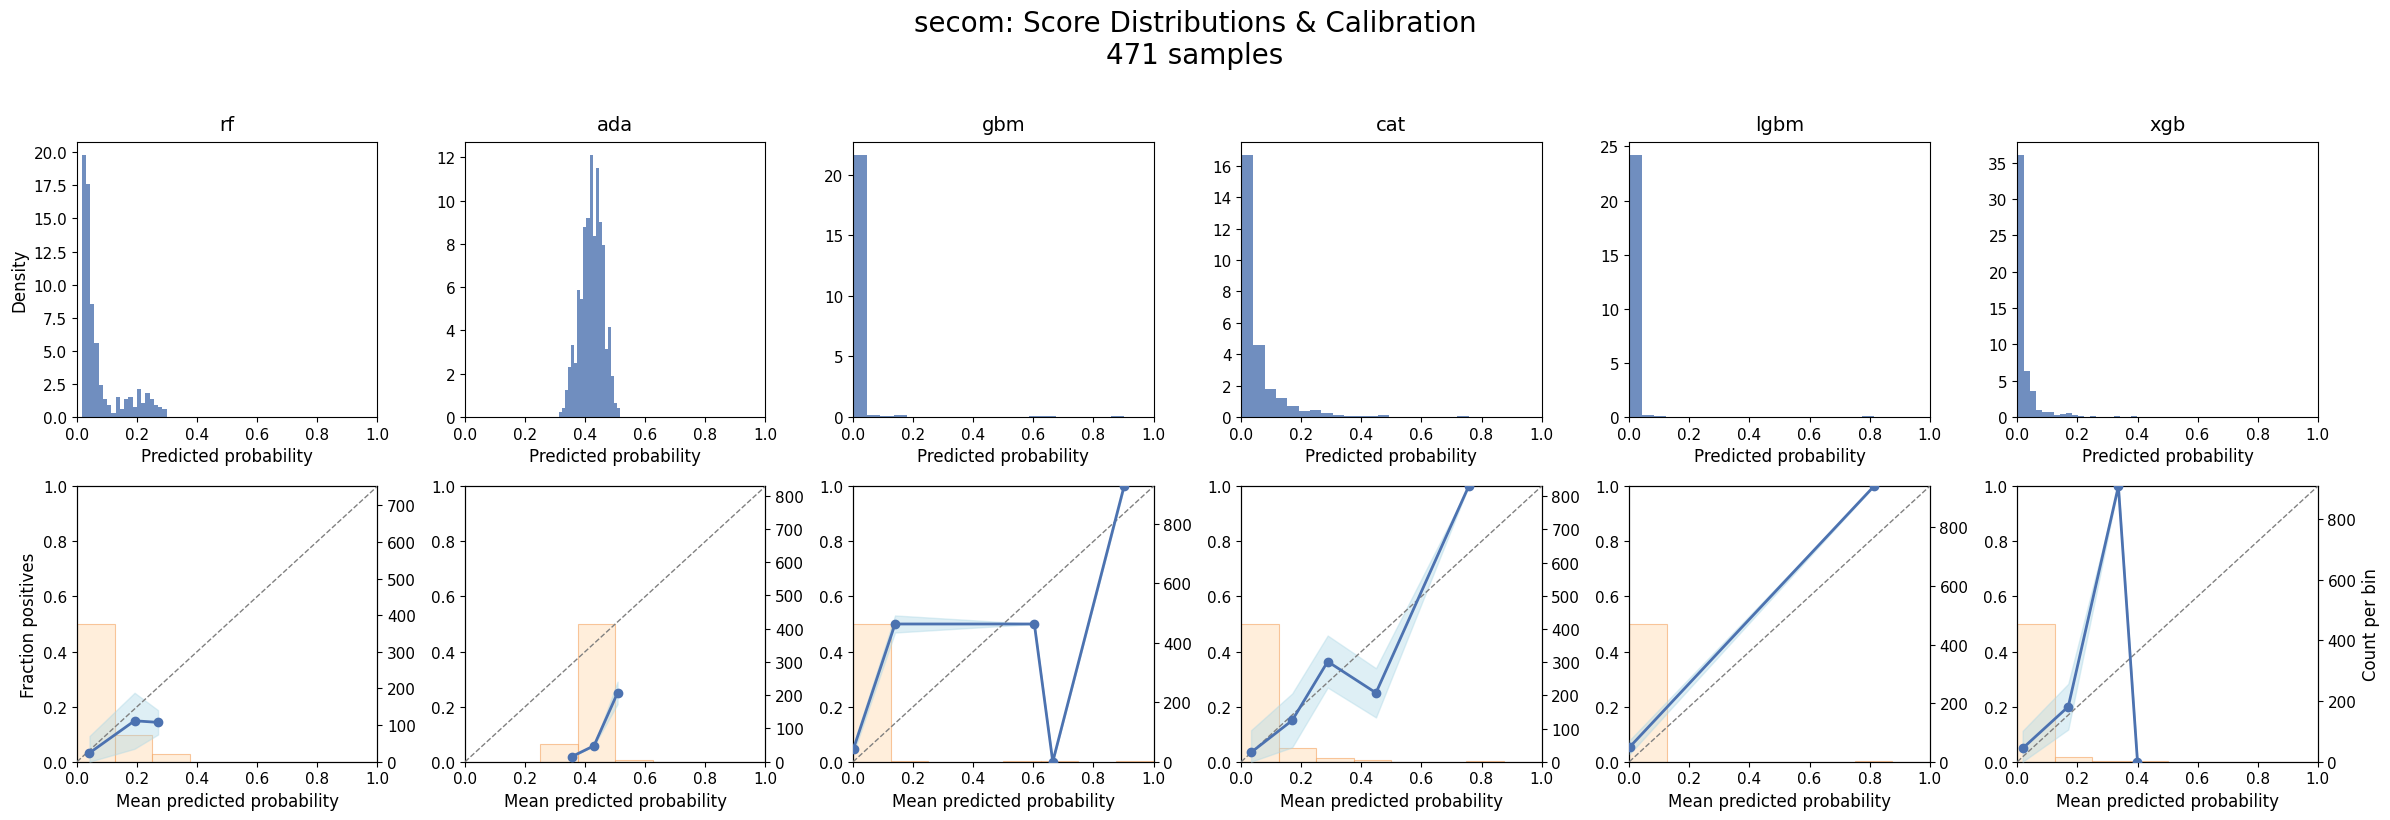

In [7]:
MODELS_DIR = "../models/ensembles-hard"

for i, dataset in enumerate(datasets):
    _, X_test, _, y_test = load_hard_dataset(dataset)

    results = {}

    for j, estimator in enumerate(models):

        # obtain probabilities
        search = joblib.load(f"{MODELS_DIR}/{dataset}_{estimator}.pkl")
        probs = search.predict_proba(X_test)[:, 1]
        results[estimator] = {"probs": probs, "model": estimator}

    # plot
    plot_models(results, y_test, dataset, bins=8)

## Calibration

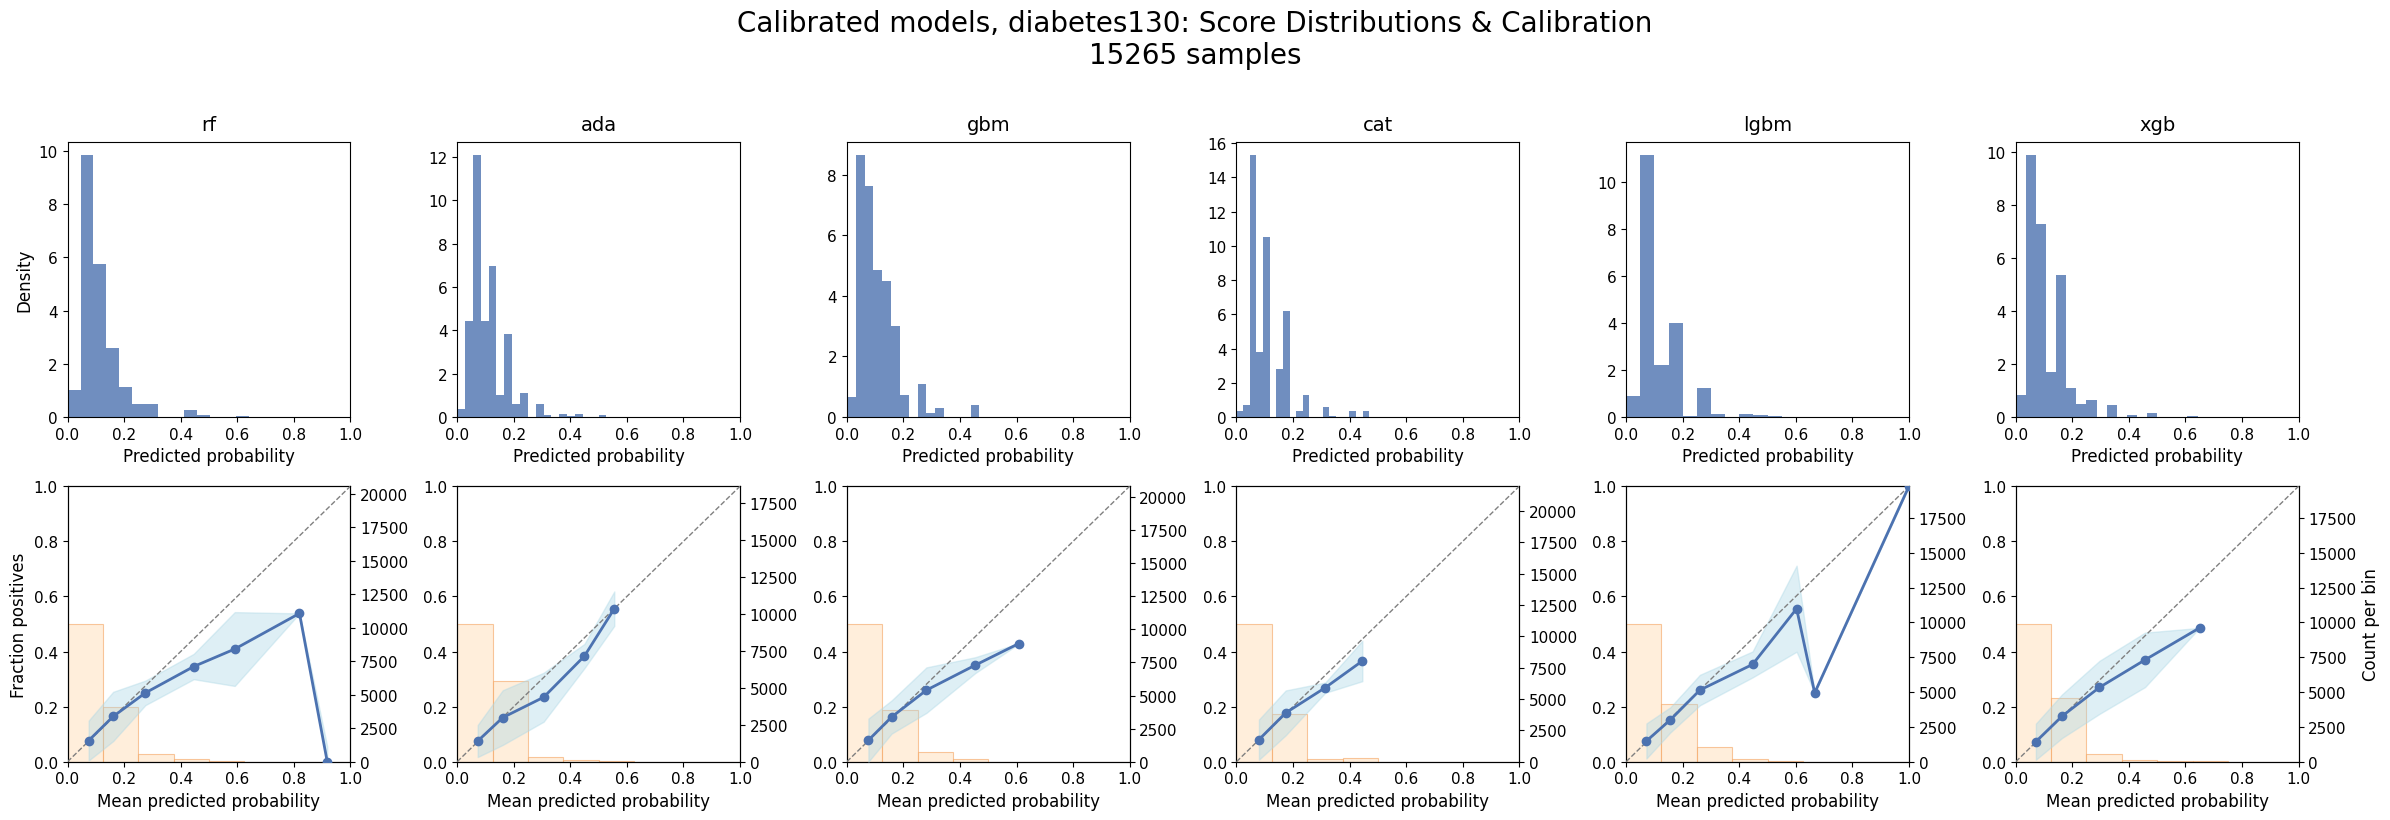

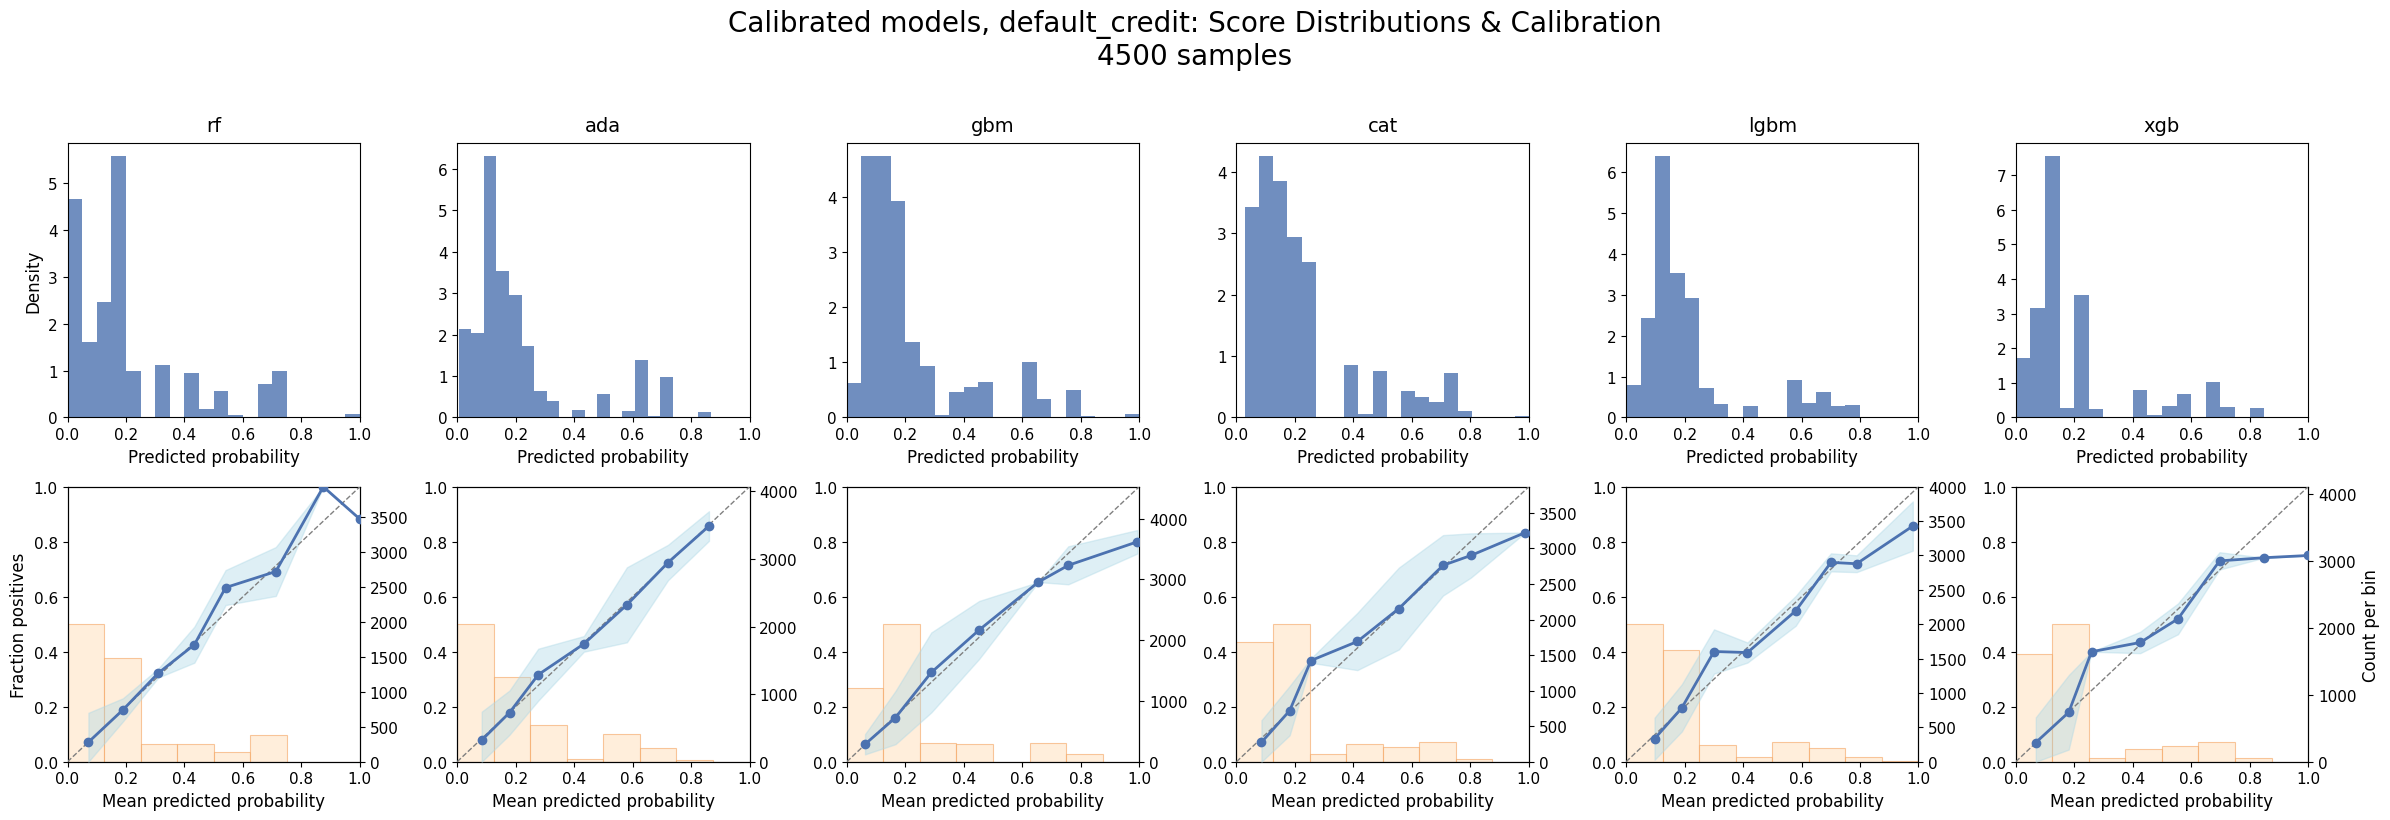

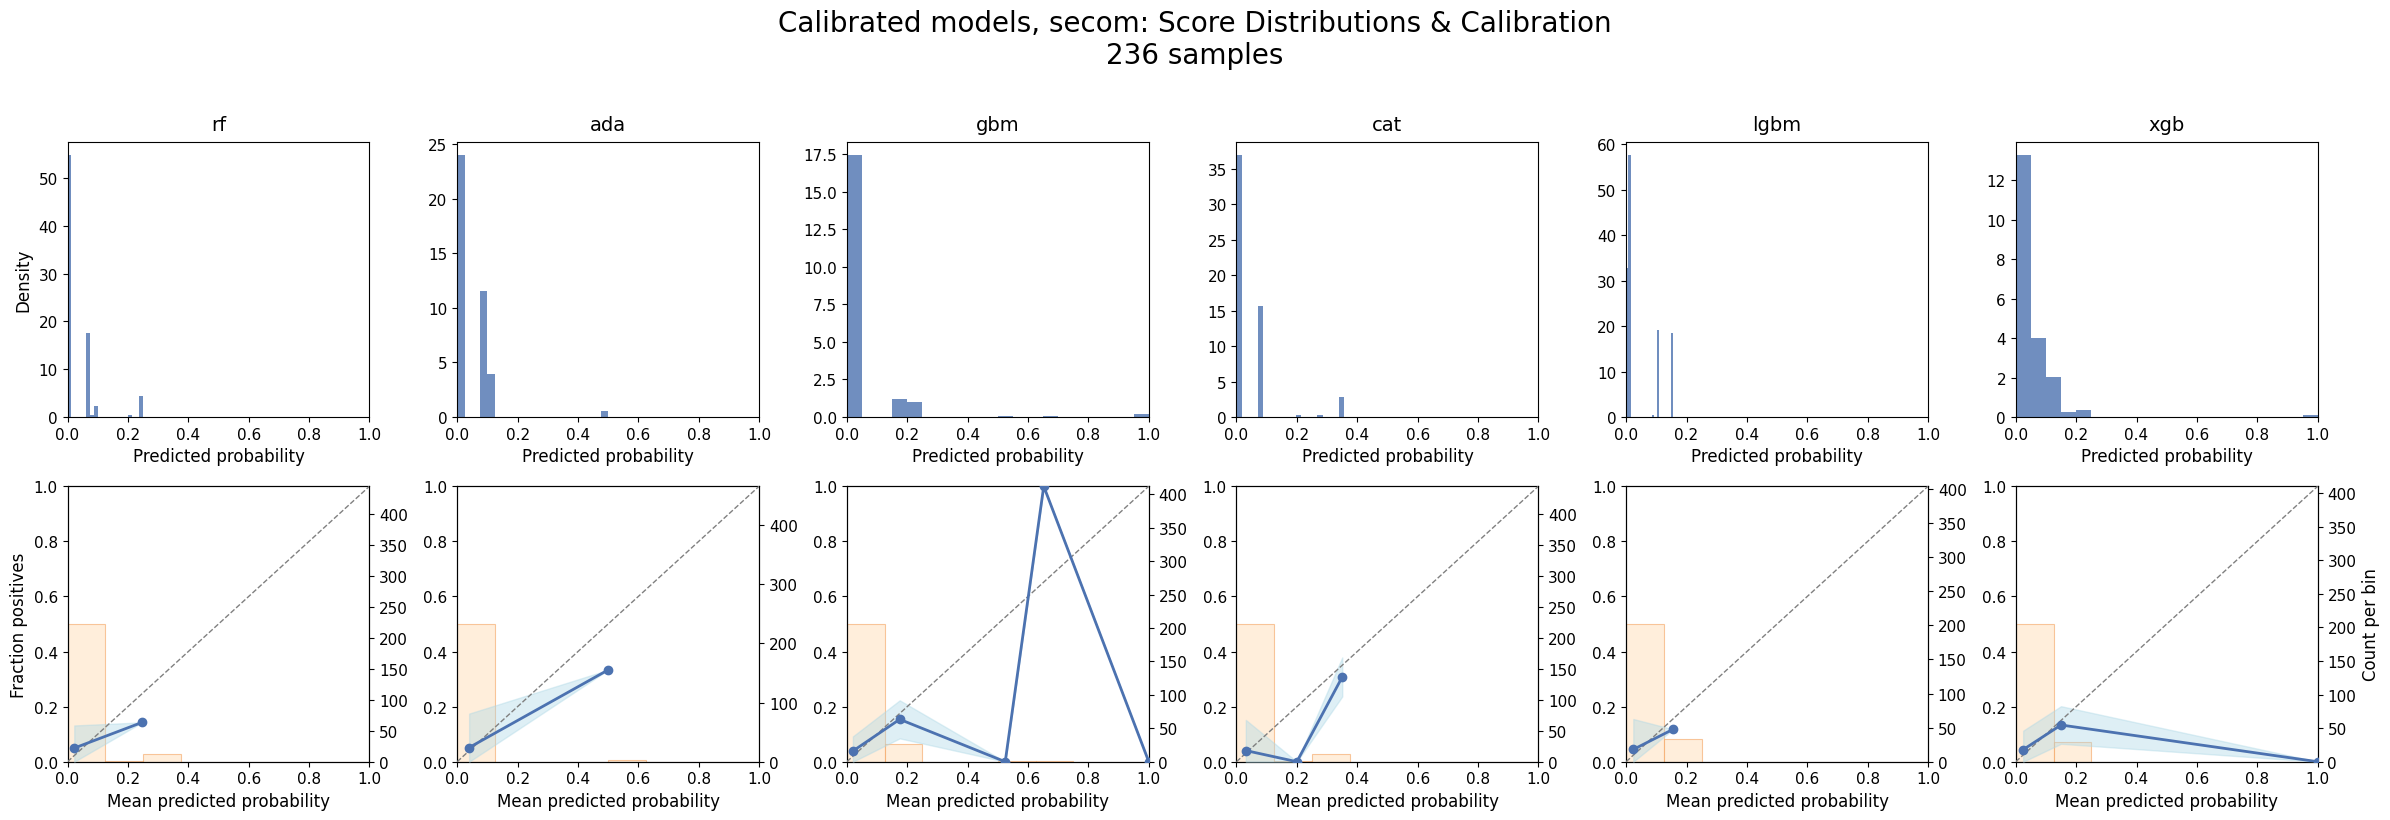

In [8]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

for i, dataset in enumerate(datasets):
    _, X_test, _, y_test = load_hard_dataset(dataset)

    X_cal, X_te,  y_cal, y_te  = train_test_split(
        X_test, y_test, test_size=0.50, random_state=42, stratify=y_test
    )

    results_cal = {}

    for j, estimator in enumerate(models):

        # Load model
        DIR = MODELS_DIR if estimator != "logit" else LOGIT_DIR
        search = joblib.load(f"{DIR}/{dataset}_{estimator}.pkl")

        # calibrate probabilities
        calibrated_model = CalibratedClassifierCV(
            FrozenEstimator(search), method="isotonic", 
        )
        calibrated_model.fit(X_cal, y_cal)
        probs = calibrated_model.predict_proba(X_te)[:, 1]
        
        results_cal[estimator] = {"probs": probs, "model": estimator}

    # plot
    plot_models(results_cal, y_te, f"Calibrated models, {dataset}", bins=8)